# WandB Multi-Run Plotting

This notebook extracts metrics from multiple Weights & Biases runs and plots them together.

In [1]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Configuration
ENTITY = "aml-fl-project"   # e.g. username or team
PROJECT = "fl-task-arithmetic"      # project name
METRIC = "accuracy"            # metric to plot
X_AXIS = "epoch"                



In [3]:
api = wandb.Api()
runs = api.runs(f"{ENTITY}/{PROJECT}")
print(f"Found {len(runs)} runs")


Found 114 runs


In [4]:
records = []

for run in runs:
    try:
        hist = run.history(keys=[METRIC], pandas=True)
        hist = hist.dropna(subset=[METRIC])
        hist['run_name'] = run.group
        records.append(hist[[METRIC, 'run_name']])
    except Exception as e:
        # print(f"Skipping {run.name}: {e}")
        continue

df = pd.concat(records)
df[X_AXIS] = df.groupby('run_name').cumcount()


## Prune the runs with the initial spikes
### Don't execute this cell multiple times!


In [5]:
# 1. Define which runs need trimming and how many initial epochs to skip
# Format: "run_name_from_wandb_group": number_of_epochs_to_skip
skip_epochs_config = {
    "baseline-fedavg-nc1-j4": 3,
    "baseline-fedavg-nc10-j4": 2,
    "baseline-fedavg-nc100-j8": 6,
    "baseline-fedavg-nc50-j8": 1,
    "baseline-fedavg-nc10-j8": 2,
    "baseline-fedavg-nc50-j16": 1,
    "baseline-fedavg-nc5-j16": 1,
       
}

# 2. Filter the DataFrame
for run_name, skip_count in skip_epochs_config.items():
    df = df[~((df['run_name'] == run_name) & (df['epoch'] < skip_count))]
# Additional filter for this run with 80 epochs
df = df[~((df['run_name'] == "baseline-fedavg-nc5-j4") & (df['epoch'] > 63))]

# df = df[~((df['run_name'] == "task-arithmetic-s90-r4-V2") & (df['epoch'] == 20))]
# df = df[~((df['run_name'] == "task_arithmetic_s70_r2-V2") & (df['epoch'] == 20))]



# shift back to 0 for the trimmed runs
df[X_AXIS] = df.groupby('run_name').cumcount()

# Baselines

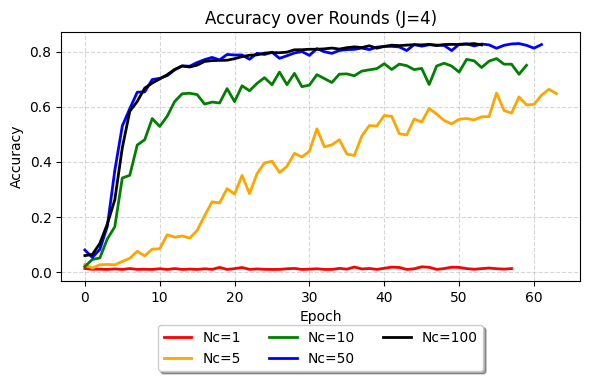

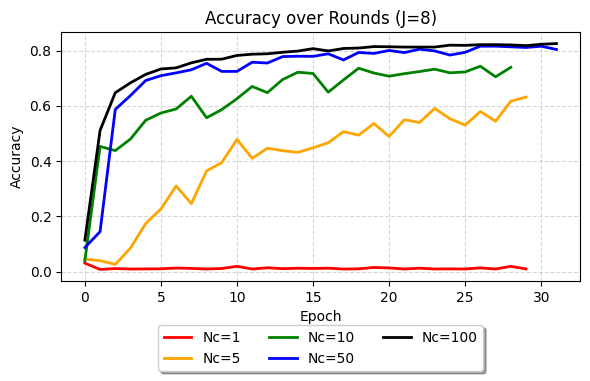

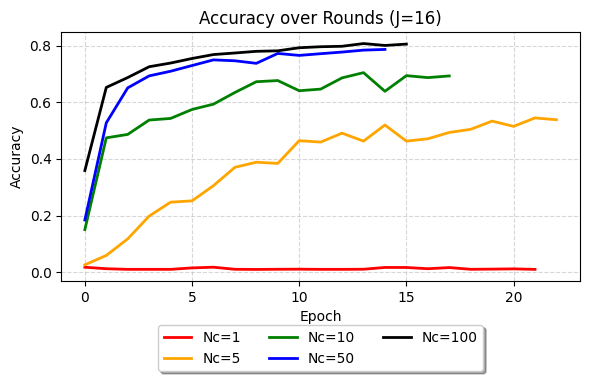

In [6]:
import matplotlib.pyplot as plt

# Set up consistent colors per Nc
colors = {
    1: "red",
    5: "orange",
    10: "green",
    50: "blue",
    100: "black"  
}

J_values = [4, 8, 16]
Nc_values = [1, 5, 10, 50, 100]

METRIC = "accuracy"  # replace with your metric column

for J in J_values:
    plt.figure(figsize=(6,4))
    plt.title(f"Accuracy over Rounds (J={J})")
    
    for Nc in Nc_values:
        # Construct group name pattern
        group_name = f"baseline-fedavg-nc{Nc}-j{J}"
        
        # Select runs belonging to this group
        g = df[df["run_name"] == group_name]
        if g.empty:
            print(f"No data for {group_name}")
            continue
        
        # Sort by step for plotting
        g = g.sort_values("epoch")
        
        plt.plot(
            g["epoch"], 
            g["accuracy"], 
            label=f"Nc={Nc}", 
            color=colors[Nc],
            linewidth=2
        )
    
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(
        loc='upper center', 
        bbox_to_anchor=(0.5, -0.15), # Position below axis
        fancybox=True, 
        shadow=True, 
        ncol=3 # Arrange in 3 columns
    )
    plt.tight_layout()
    plt.show()


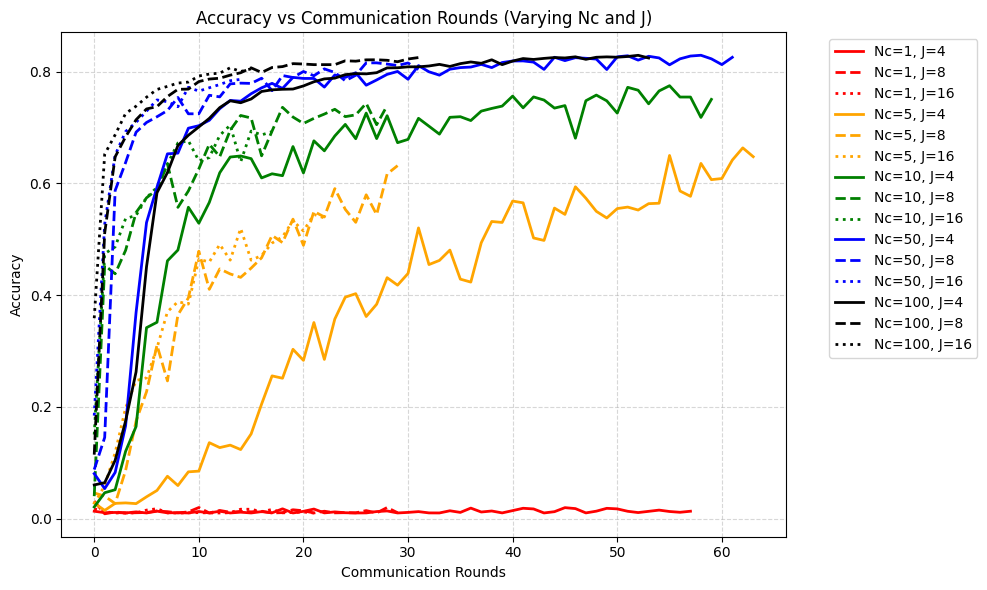

In [ ]:
import re

# Define style mappings
colors = {
    1: "red",
    5: "orange",
    10: "green",
    50: "blue",
    100: "black"
}

line_styles = {
    4: "-",      # solid
    8: "--",     # dashed
    16: ":"      # dotted
}

# Function to extract Nc and J from the run group name
def parse_run_params(run_name):
    # Matches patterns like "...-nc100-j16..."
    match = re.search(r"nc(\d+)-j(\d+)", run_name)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None

plt.figure(figsize=(10, 6))

# Identify all unique runs in the dataframe
run_names = df['run_name'].unique()

# Filter and sort runs to ensure the legend is logical
valid_runs = []
for r in run_names:
    nc, j = parse_run_params(r)
    # Only include if we found the params and they match our style keys
    if nc in colors and j in line_styles:
        valid_runs.append((nc, j, r))

# Sort by Nc, then by J
valid_runs.sort(key=lambda x: (x[0], x[1]))

# Plot each run
for nc, j, r_name in valid_runs:
    subset = df[df['run_name'] == r_name].sort_values(X_AXIS)
    
    plt.plot(
        subset[X_AXIS], 
        subset[METRIC], 
        label=f"Nc={nc}, J={j}", 
        color=colors[nc], 
        linestyle=line_styles[j],
        linewidth=2
    )

plt.title("Accuracy vs Epoch (Varying Nc and J)")
plt.xlabel("Epoch")
plt.ylabel(METRIC.capitalize())
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside if crowded
plt.tight_layout()
plt.show()

# Task arithmetic

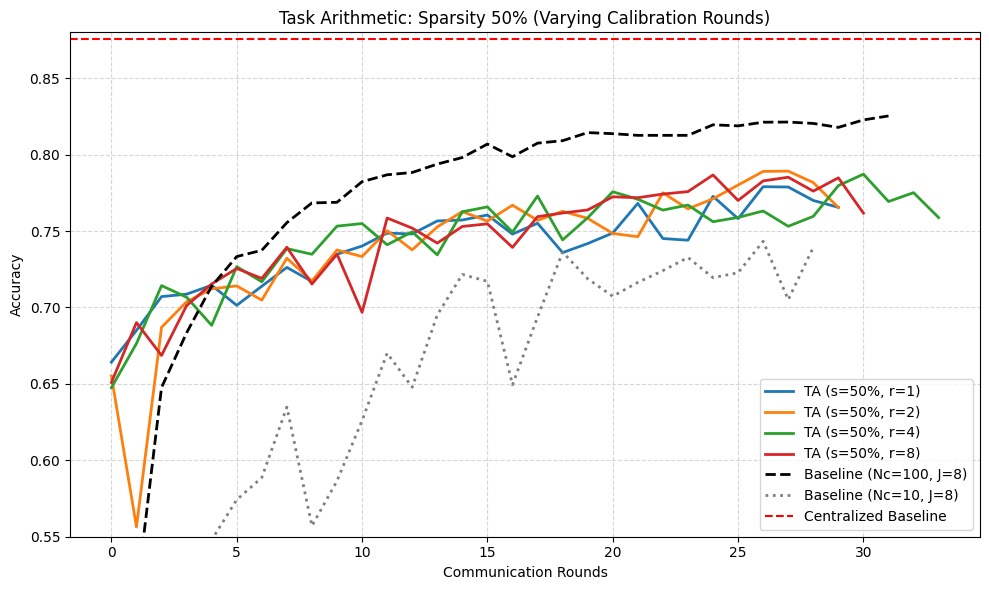

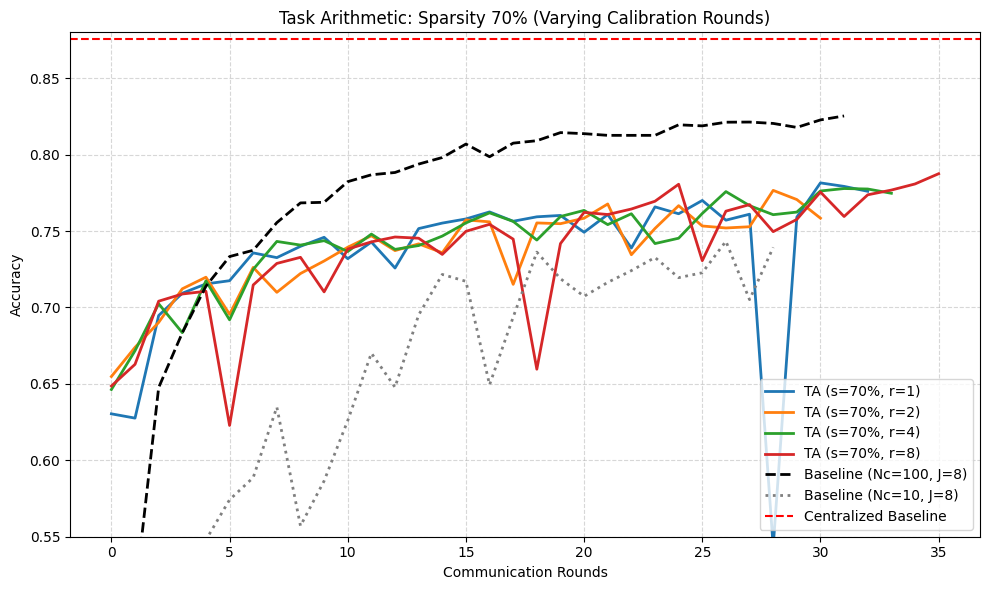

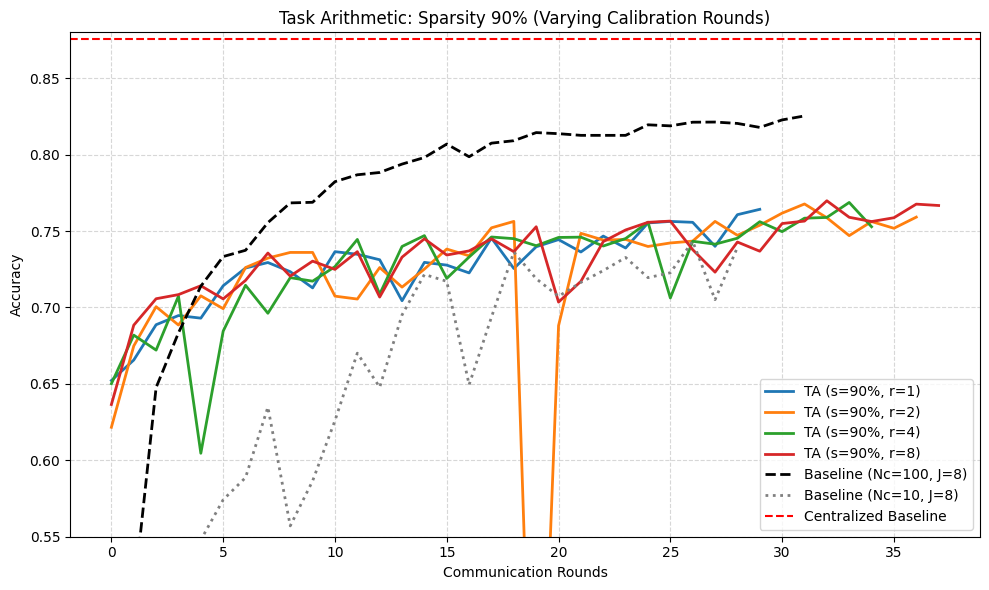

In [ ]:
import matplotlib.pyplot as plt

# 1. Define Group Names Mapping based on config files
# Structure: {sparsity: {rounds: 'wandb_group_name'}}
# Note: Inconsistencies in naming (e.g., 'V2-' prefix) are handled here.
# 1. Define Group Names Mapping (Same as before)
ta_groups = {
    50: {
        1: "V2-task-arithmetic-s50-r1-V2",
        2: "V2-task-arithmetic-s50-r2-V2",
        4: "task-arithmetic-s50-r4-V2",
        8: "task-arithmetic-s50-r8-V2"
    },
    70: {
        1: "task-arithmetic-s70-r1-V2",
        2: "task-arithmetic-s70-r2",
        4: "task-arithmetic-s70-r4-V2",
        8: "task-arithmetic-s70-r8-V2"
    },
    90: {
        1: "task-arithmetic-s90-r1-V2",
        2: "task-arithmetic-s90-r2-V2",
        4: "task-arithmetic-s90-r4-V2",
        8: "task-arithmetic-s90-r8-V2"
    }
}

baseline_nc100 = "baseline-fedavg-nc100-j8"
baseline_nc10 = "baseline-fedavg-nc10-j8"
CENTRALIZED_ACC = 0.8755 
METRIC = "accuracy"
X_AXIS = "epoch"

sparsities = [50, 70, 90]

for s in sparsities:
    plt.figure(figsize=(10, 6))
    
    # Plot Task Arithmetic runs
    for r, group_name in ta_groups[s].items():
        subset = df[df['run_name'] == group_name].sort_values(X_AXIS)
        if not subset.empty:
            plt.plot(subset[X_AXIS], subset[METRIC], label=f"TA (s={s}%, r={r})", linewidth=2)

    # Plot Baselines
    base100 = df[df['run_name'] == baseline_nc100].sort_values(X_AXIS)
    if not base100.empty:
        plt.plot(base100[X_AXIS], base100[METRIC], label="Baseline (Nc=100, J=8)", 
                 color='black', linestyle='--', linewidth=2)
        
    base10 = df[df['run_name'] == baseline_nc10].sort_values(X_AXIS)
    if not base10.empty:
        plt.plot(base10[X_AXIS], base10[METRIC], label="Baseline (Nc=10, J=8)", 
                 color='grey', linestyle=':', linewidth=2)

    plt.axhline(y=CENTRALIZED_ACC, color='red', linestyle='--', label="Centralized Baseline")

    # --- KEY CHANGE: Zoom in on the Y-axis ---
    # Adjust these values based on your exact data range
    plt.ylim(0.55, 0.88) 
    # -----------------------------------------

    plt.title(f"Task Arithmetic: Sparsity {s}% (Varying Calibration Rounds)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc='lower right') # Moved legend to avoid covering lines
    plt.tight_layout()
    plt.show()

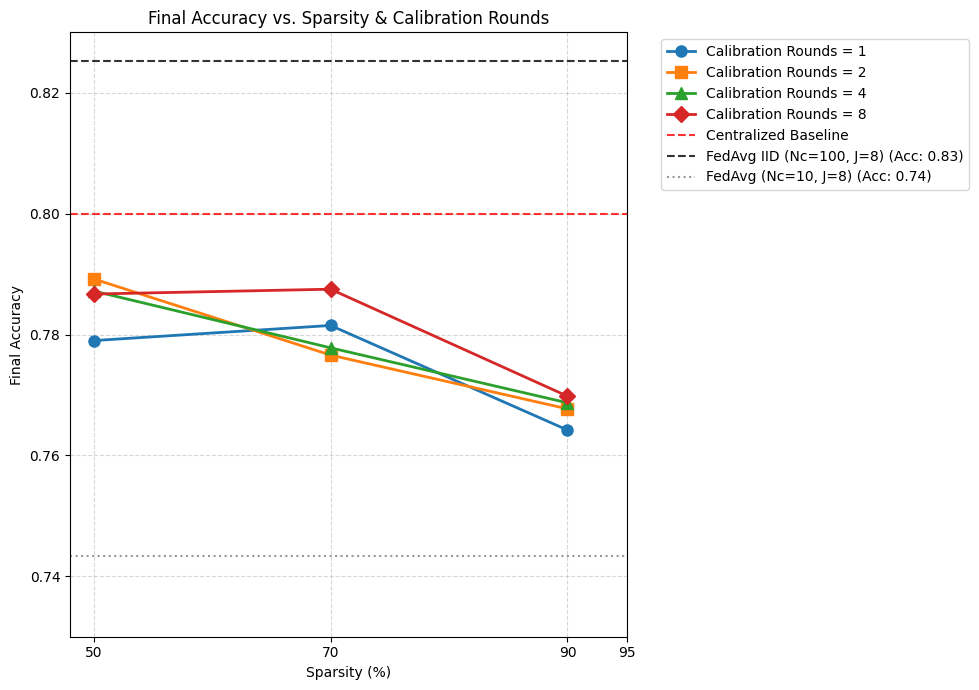

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Define Run Mapping (Sparsity -> Rounds -> Group Name)
ta_groups_config = {
    50: {
        1: "V2-task-arithmetic-s50-r1-V2",
        2: "V2-task-arithmetic-s50-r2-V2",
        4: "task-arithmetic-s50-r4-V2",
        8: "task-arithmetic-s50-r8-V2"
    },
    70: {
        1: "task-arithmetic-s70-r1-V2",
        2: "task-arithmetic-s70-r2",
        4: "task-arithmetic-s70-r4-V2",
        8: "task-arithmetic-s70-r8-V2"
    },
    90: {
        1: "task-arithmetic-s90-r1-V2",
        2: "task-arithmetic-s90-r2-V2",
        4: "task-arithmetic-s90-r4-V2",
        8: "task-arithmetic-s90-r8-V2"
    },
    95: {
        1: "task-arithmetic-s95-r1-V2",
        2: "task-arithmetic-s95-r2-V2",
        4: "task-arithmetic-s95-r4-V2",
        8: "task-arithmetic-s95-r8-V2"
    }
}

baselines = {
    "FedAvg IID (Nc=100, J=8)": "baseline-fedavg-nc100-j8",
    "FedAvg (Nc=10, J=8)": "baseline-fedavg-nc10-j8"
}
CENTRALIZED_ACC = 0.80  # Fixed value

# 2. Extract Final (Max) Accuracy for each run
data = []

# Process Task Arithmetic runs
for sparsity, rounds_dict in ta_groups_config.items():
    for r, run_name in rounds_dict.items():
        # Get max accuracy for this run
        run_data = df[df['run_name'] == run_name][METRIC]
        if not run_data.empty:
            max_acc = run_data.max()
            data.append({
                "Sparsity": sparsity,
                "Rounds": r,
                "Accuracy": max_acc,
                "Type": "Task Arithmetic"
            })

# Process Baselines
baseline_vals = {}
for label, run_name in baselines.items():
    run_data = df[df['run_name'] == run_name][METRIC]
    if not run_data.empty:
        baseline_vals[label] = run_data.max()
    else:
        baseline_vals[label] = None

# Create DataFrame for easier plotting
res_df = pd.DataFrame(data)

# 3. Plotting
plt.figure(figsize=(10, 7))

# Plot lines for each Calibration Round count
rounds_options = sorted(res_df["Rounds"].unique())
markers = ['o', 's', '^', 'D'] # distinct markers for rounds

for i, r in enumerate(rounds_options):
    subset = res_df[res_df["Rounds"] == r].sort_values("Sparsity")
    plt.plot(
        subset["Sparsity"], 
        subset["Accuracy"], 
        marker=markers[i], 
        linewidth=2, 
        markersize=8,
        label=f"Calibration Rounds = {r}"
    )

# Plot Horizontal Baselines
colors = ['black', 'grey']
styles = ['--', ':']

# Centralized
plt.axhline(y=CENTRALIZED_ACC, color='red', linestyle='--', label="Centralized Baseline", alpha=0.8)

# FedAvg Baselines
for i, (label, val) in enumerate(baseline_vals.items()):
    if val is not None:
        plt.axhline(y=val, color=colors[i], linestyle=styles[i], label=f"{label} (Acc: {val:.2f})", alpha=0.8)

# Styling
plt.title("Final Accuracy vs. Sparsity & Calibration Rounds")
plt.xlabel("Sparsity (%)")
plt.ylabel("Final Accuracy")
plt.xticks([50, 70, 90, 95])  # Ensure only relevant ticks show
plt.grid(True, linestyle="--", alpha=0.5)
plt.ylim(0.73, 0.83) # Zoom in based on previous observations

# Legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Extension

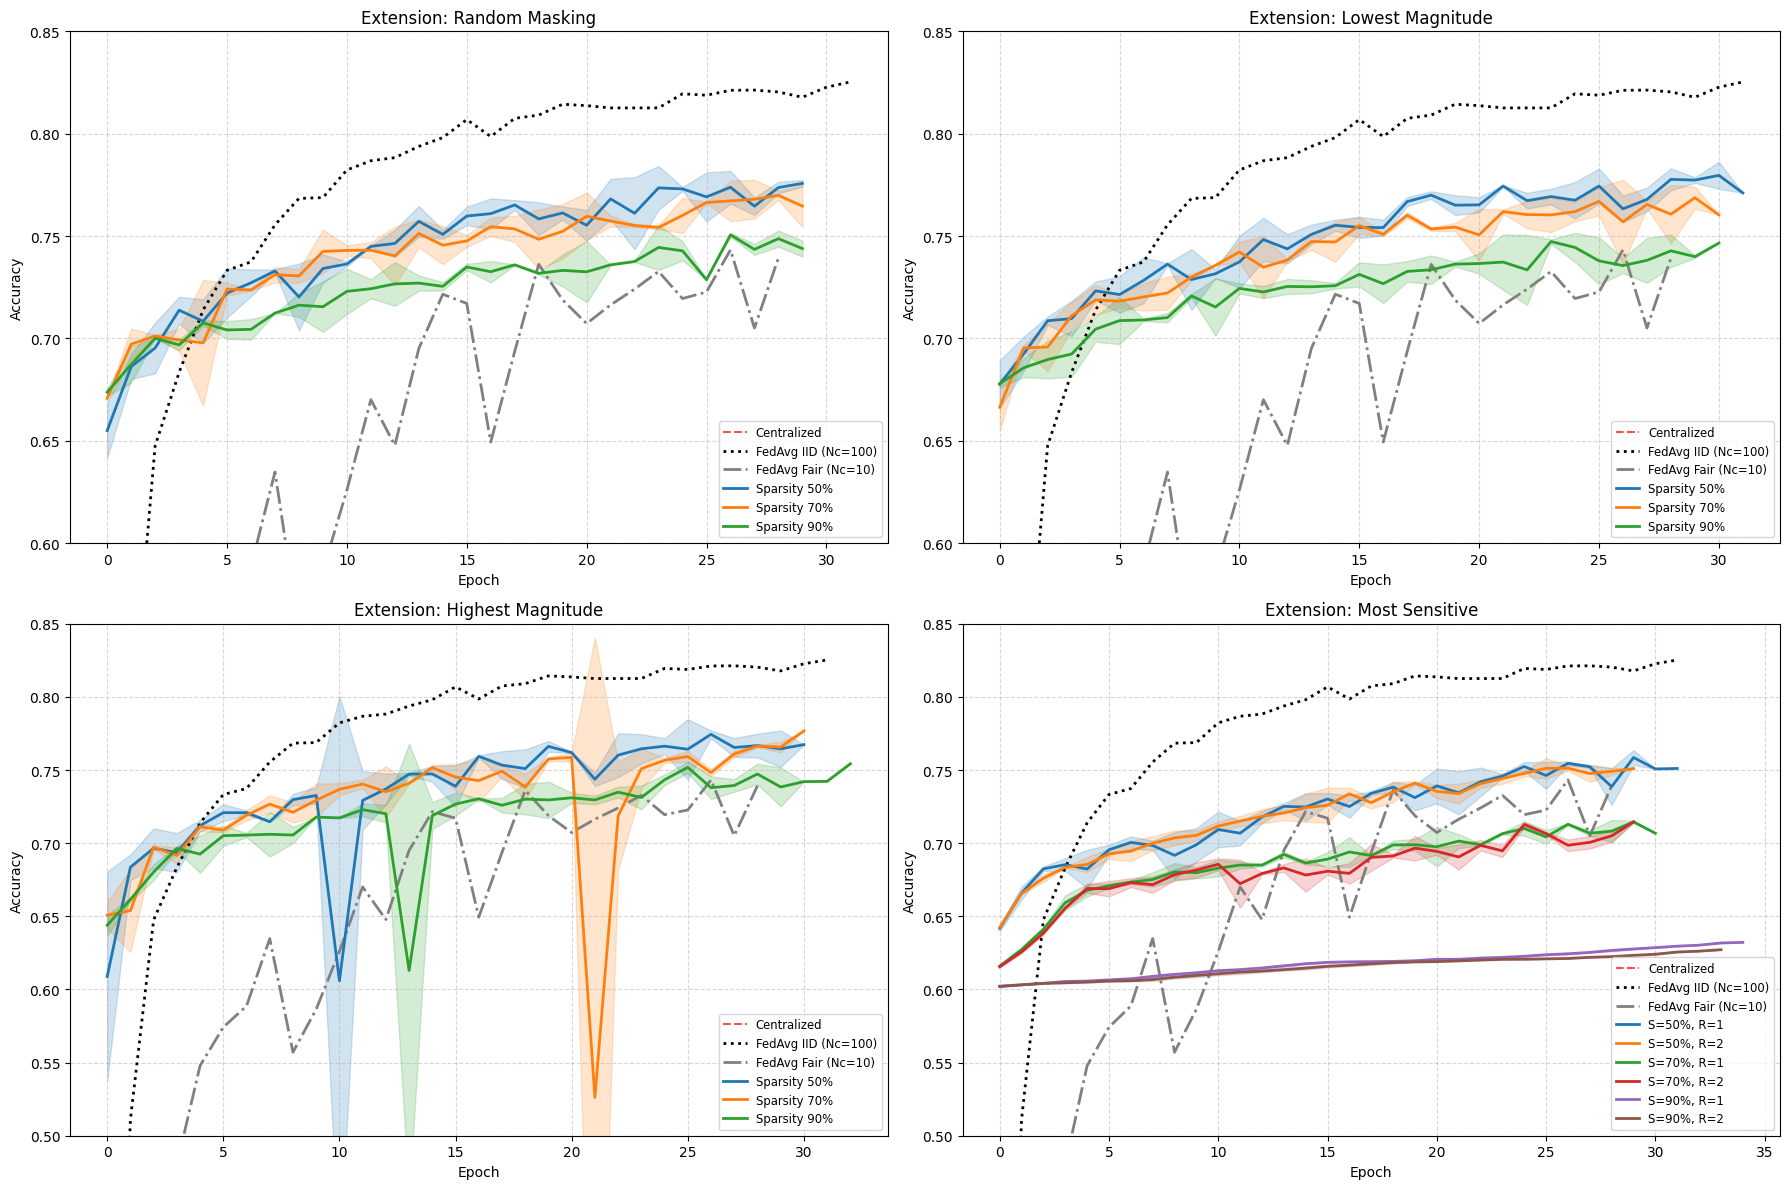

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import re
import numpy as np

# --- Configuration & Constants ---
CENTRALIZED_ACC = 0.8733
METRIC = "accuracy"
X_AXIS = "epoch"

# Define Baseline Groups
BASELINE_IID = "baseline-fedavg-nc100-j8"
BASELINE_FAIR = "baseline-fedavg-nc10-j8"
BEST_TA_GROUP = "task_arithmetic_s70_r8-V2" 

# Helper function to normalize run names (remove -RUNx suffix)
def get_base_name(run_name):
    # Regex to remove -RUN1, -RUN2, etc. at the end
    return re.sub(r"-RUN\d+$", "", run_name)

# Create a 'base_name' column for aggregation
df['base_name'] = df['run_name'].apply(get_base_name)

# Pre-calculate aggregated data (mean & std) for all base_names
# Group by base_name and epoch
agg_df = df.groupby(['base_name', X_AXIS])[METRIC].agg(['mean', 'std']).reset_index()

# Function to plot a single extension chart
def plot_extension(extension_name, config_dict, ax, ylim=(0.6, 0.85)):
    # 1. Plot Baselines (Fixed for all charts)
    
    # Centralized
    ax.axhline(y=CENTRALIZED_ACC, color='red', linestyle='--', label="Centralized", alpha=0.7)
    
    # FedAvg IID
    iid_data = df[df['run_name'] == BASELINE_IID].sort_values(X_AXIS)
    if not iid_data.empty:
        ax.plot(iid_data[X_AXIS], iid_data[METRIC], color='black', linestyle=':', label="FedAvg IID (Nc=100)", linewidth=2)
        
    # FedAvg Fair
    fair_data = df[df['run_name'] == BASELINE_FAIR].sort_values(X_AXIS)
    if not fair_data.empty:
        ax.plot(fair_data[X_AXIS], fair_data[METRIC], color='grey', linestyle='-.', label="FedAvg Fair (Nc=10)", linewidth=2)

    # Best Task Arithmetic
    # Check if we need to aggregate or if it's a single run
    ta_base = get_base_name(BEST_TA_GROUP)
    ta_data = agg_df[agg_df['base_name'] == ta_base].sort_values(X_AXIS)
    if not ta_data.empty:
        ax.plot(ta_data[X_AXIS], ta_data['mean'], color='purple', linestyle='-', label="Best Task Arithmetic", linewidth=2)
    
    # 2. Plot Extension Curves
    # Iterate through the specific configs for this extension
    for label, base_group in config_dict.items():
        subset = agg_df[agg_df['base_name'] == base_group].sort_values(X_AXIS)
        
        if not subset.empty:
            # Plot Mean Line
            line, = ax.plot(subset[X_AXIS], subset['mean'], label=label, linewidth=2)
            
            # Fill Standard Deviation
            ax.fill_between(
                subset[X_AXIS], 
                subset['mean'] - subset['std'].fillna(0), 
                subset['mean'] + subset['std'].fillna(0), 
                color=line.get_color(), 
                alpha=0.2
            )

    # Formatting
    ax.set_title(f"Extension: {extension_name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_ylim(ylim) 
    ax.legend(fontsize='small', loc='lower right')

# --- Define Extension Configurations ---

# 1. Random Masking (Sparsity 50, 70, 90)
random_configs = {
    "Sparsity 50%": "random-masking-s50",
    "Sparsity 70%": "random-masking-s70",
    "Sparsity 90%": "random-masking-s90"
}

# 2. Lowest Magnitude (Sparsity 50, 70, 90)
low_mag_configs = {
    "Sparsity 50%": "lowest-magnitude-s50",
    "Sparsity 70%": "lowest-magnitude-s70",
    "Sparsity 90%": "lowest-magnitude-s90"
}

# 3. Highest Magnitude (Sparsity 50, 70, 90)
high_mag_configs = {
    "Sparsity 50%": "highest-magnitude-s50",
    "Sparsity 70%": "highest-magnitude-s70",
    "Sparsity 90%": "highest-magnitude-s90"
}

# 4. Most Sensitive (Sparsity 50/70/90 x Rounds 1/2)
# Note: Base names derived from config patterns (e.g., most-sensitive-s50-r1)
most_sens_configs = {
    "S=50%, R=1": "most-sensitive-s50-r1",
    "S=50%, R=2": "most-sensitive-s50-r2",
    "S=70%, R=1": "most-sensitive-s70-r1",
    "S=70%, R=2": "most-sensitive-s70-r2",
    "S=90%, R=1": "most-sensitive-s90-r1",
    "S=90%, R=2": "most-sensitive-s90-r2",
}

# --- Generate Plots ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

plot_extension("Random Masking", random_configs, axes[0, 0], ylim=(0.6, 0.85))
plot_extension("Lowest Magnitude", low_mag_configs, axes[0, 1], ylim=(0.6, 0.85))
plot_extension("Highest Magnitude", high_mag_configs, axes[1, 0], ylim=(0.5, 0.85))
plot_extension("Most Sensitive", most_sens_configs, axes[1, 1], ylim=(0.5, 0.85))

plt.tight_layout()
plt.show()